In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
df = pd.read_csv("../../data/Gaming_Academic_Performance.csv")

In [3]:
conditions = [
    df["grades"] >= 80,  # good
    df["grades"] >= 55,  # sufficient
]
choices = ["good", "sufficient"]

df["grade_category"] = np.select(conditions, choices, default="fail")

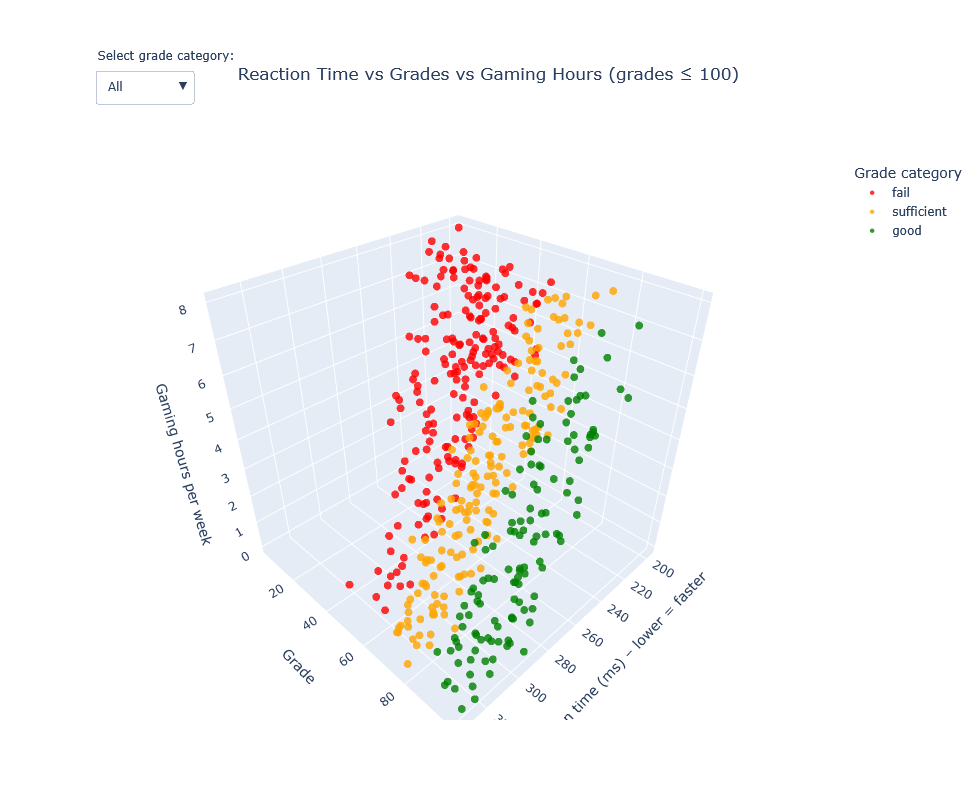

In [13]:
import plotly.graph_objects as go

# 1. Create grade_category from grades
df["grade_category"] = pd.cut(
    df["grades"],
    bins=[0, 60, 80, float("inf")],
    labels=["fail", "sufficient", "good"],
    right=False
)

# 2. Create study_hours_category from study_hours
df["study_hours_category"] = pd.cut(
    df["study_hours"],
    bins=[0, 3, 6, float("inf")],
    labels=["low", "average", "high"],
    right=False
)

# 3. Filter out unrealistic grades > 100
df_filtered = df[df["grades"] <= 100].copy()

# 4. Take a smaller sample if there are many rows
if len(df_filtered) > 500:
    df_small = df_filtered.sample(n=500, random_state=0)
else:
    df_small = df_filtered.copy()

# Category settings for grade category
categories = ["fail", "sufficient", "good"]
colors = {
    "fail": "red",
    "sufficient": "orange",
    "good": "green",
}

# 5. Build 3D scatter plot with one trace per grade_category
fig = go.Figure()

for cat in categories:
    subset = df_small[df_small["grade_category"] == cat]

    fig.add_trace(go.Scatter3d(
        x=subset["reaction_time_ms"],
        y=subset["grades"],
        z=subset["gaming_hours"],
        mode="markers",
        name=cat,
        marker=dict(
            size=4.5,
            opacity=0.8,
            color=colors[cat],
        ),
        customdata=subset[["study_hours", "study_hours_category", "grades"]].values,
        hovertemplate=(
            "Grade category: " + cat + "<br>"
            "Reaction time (ms): %{x}<br>"
            "Grade: %{y}<br>"
            "Gaming hours/week: %{z}<br>"
            "Study hours/week: %{customdata[0]}<br>"
            "Study hours category: %{customdata[1]}<extra></extra>"
        )
    ))

# Dropdown buttons for grade category
buttons = [
    dict(
        label="All",
        method="update",
        args=[{"visible": [True, True, True]}]
    )
]

for i, cat in enumerate(categories):
    visible = [False] * len(categories)
    visible[i] = True
    buttons.append(
        dict(
            label=cat.capitalize(),
            method="update",
            args=[{"visible": visible}]
        )
    )

# Layout
fig.update_layout(
    title=dict(
        text="Reaction Time vs Grades vs Gaming Hours (grades ≤ 100)",
        x=0.5,
        xanchor="center"
    ),
    width=1000,
    height=800,
    margin=dict(t=160),
    scene=dict(
        xaxis_title="Reaction time (ms) – lower = faster",
        yaxis_title="Grade",
        zaxis_title="Gaming hours per week",
    ),
    legend_title_text="Grade category",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.16,
            xanchor="left",
            yanchor="top"
        )
    ],
    annotations=[
        dict(
            text="Select grade category:",
            x=0.02,
            y=1.205,
            xref="paper",
            yref="paper",
            showarrow=False
        )
    ]
)

fig.show()